### Import liberaries

In [72]:
!pip install pandas numpy matplotlib seaborn

In [73]:
import pandas as pd
import numpy as np

from datetime import datetime

import seaborn as sns
import matplotlib.pyplot as plt


# set pandas to display all columns
pd.set_option('display.max_columns',None)

### Load data

In [74]:
listing_df = pd.read_csv('../data/raw/Listings.csv' ,
                            encoding = "ISO-8859-1" ,           # this will handle the special characters
                            low_memory=False                    # this will prevent dtype warning due to mixed types in columns
                        ) 
listing_df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Vaugirard,NaN,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Passy,NaN,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


### Data cleaning 

#### first check the city data and filter it 

In [75]:
listing_df['city'].unique()            # then we will filter this to work with paris data only 

<StringArray>
[         'Paris',       'New York',        'Bangkok', 'Rio de Janeiro',
         'Sydney',       'Istanbul',           'Rome',      'Hong Kong',
    'Mexico City',      'Cape Town']
Length: 10, dtype: str

In [76]:
def data_filtering_pipeline(listing_df):
    paris_df=listing_df.copy() 
    # work with paris data only 
    paris_df = paris_df[paris_df['city'] == 'Paris']
    return paris_df

paris_df = data_filtering_pipeline(listing_df)
paris_df['city'].unique()

<StringArray>
['Paris']
Length: 1, dtype: str

#### Explore data 

In [77]:
paris_df.info()           # to check data type per column

<class 'pandas.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   64690 non-null  int64  
 1   name                         64627 non-null  str    
 2   host_id                      64690 non-null  int64  
 3   host_since                   64657 non-null  str    
 4   host_location                64522 non-null  str    
 5   host_response_time           23346 non-null  str    
 6   host_response_rate           23346 non-null  float64
 7   host_acceptance_rate         31919 non-null  float64
 8   host_is_superhost            64657 non-null  str    
 9   host_total_listings_count    64657 non-null  float64
 10  host_has_profile_pic         64657 non-null  str    
 11  host_identity_verified       64657 non-null  str    
 12  neighbourhood                64690 non-null  str    
 13  district                     0 

In [78]:
paris_df.describe()

,listing_id,host_id,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,6.469000e+04,6.469000e+04,23346.000000,31919.000000,64657.000000,64690.000000,64690.000000,64690.000000,51286.000000,64690.000000,64690.000000,6.469000e+04,48036.000000,47989.000000,47998.000000,47972.000000,47991.000000,47971.000000,47972.000000
mean,2.423686e+07,8.796396e+07,0.859150,0.806684,11.739348,48.864199,2.345289,3.037997,1.369224,113.096445,5.741768,8.508504e+02,93.063931,9.595157,9.206446,9.686984,9.713071,9.685352,9.276703
std,1.432657e+07,1.048625e+08,0.280421,0.302462,71.333488,0.018327,0.033275,1.588766,0.952845,214.433668,44.877425,3.932168e+04,8.944810,0.847168,1.107371,0.775500,0.767611,0.702251,0.943098
min,2.577000e+03,2.626000e+03,0.000000,0.000000,0.000000,48.813170,2.228680,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.180961e+07,1.274923e+07,0.890000,0.750000,1.000000,48.850870,2.324310,2.000000,1.000000,59.000000,1.000000,3.000000e+01,90.000000,9.000000,9.000000,10.000000,10.000000,10.000000,9.000000
50%,2.394850e+07,3.737947e+07,1.000000,0.970000,1.000000,48.865470,2.348180,2.000000,1.000000,80.000000,2.000000,1.125000e+03,95.000000,10.000000,9.000000,10.000000,10.000000,10.000000,9.000000
75%,3.720798e+07,1.316600e+08,1.000000,1.000000,2.000000,48.879100,2.370460,4.000000,2.000000,120.000000,4.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,4.809185e+07,3.876640e+08,1.000000,1.000000,1105.000000,48.904910,2.467050,16.000000,50.000000,12000.000000,9999.000000,1.000000e+07,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [79]:
paris_df.isnull().sum().sort_values(ascending=False)

district                       64690
host_response_time             41344
host_response_rate             41344
host_acceptance_rate           32771
review_scores_location         16719
review_scores_value            16718
review_scores_checkin          16718
review_scores_accuracy         16701
review_scores_communication    16699
review_scores_cleanliness      16692
review_scores_rating           16654
bedrooms                       13404
host_location                    168
name                              63
host_total_listings_count         33
host_is_superhost                 33
host_since                        33
host_identity_verified            33
host_has_profile_pic              33
listing_id                         0
longitude                          0
host_id                            0
latitude                           0
city                               0
neighbourhood                      0
maximum_nights                     0
minimum_nights                     0
p

#### change data types if needed

In [80]:
def convert_string_to_boolean(value):
    val=str(value).lower()
    if val == 't':
        return True
    else : 
        return False

In [81]:
bool_columns=['host_is_superhost','host_has_profile_pic','host_identity_verified' , 'instant_bookable']
for col in bool_columns:
    paris_df[col]=paris_df[col].apply(convert_string_to_boolean)

paris_df[bool_columns].dtypes

host_is_superhost         bool
host_has_profile_pic      bool
host_identity_verified    bool
instant_bookable          bool
dtype: object

In [82]:
paris_df['host_since'] = pd.to_datetime(paris_df['host_since'])
paris_df['host_since'].dtype

dtype('<M8[us]')

In [83]:
paris_df['bedrooms'] = paris_df['bedrooms'].astype('Int64')
paris_df['bedrooms'].dtype

Int64Dtype()

#### drop or fill null values 

In [84]:
paris_df.drop(columns=['district','name'], inplace=True)  # dropping this column as it has 100% missing values

In [85]:
def clean_bedrooms(df):
    """
    Handles missing values in the 'bedrooms' column:
    1. Sets small listings (accommodates <= 2) to 0 bedrooms (Studios).
    2. Fills remaining NaNs using the median bedroom count for each 'accommodates' group.
    3. Converts to nullable Integer type.
    """
    # Create a copy so we don't modify the original dataframe by accident
    df = df.copy()

    # 1. handle if bedrooms is NaN and it's for 1-2 people, it's a Studio (0)
    df.loc[(df['bedrooms'].isna()) & (df['accommodates'] <= 2), 'bedrooms'] = 0

    # 2. Smart Fill based on 'accommodates' groups
    df['bedrooms'] = df['bedrooms'].fillna(
        df.groupby('accommodates')['bedrooms'].transform('median')
    )

    # 3. Convert to Int64 (Capital 'I' allows for potential remaining NaNs if any)
    df['bedrooms'] = df['bedrooms'].astype('Int64')
    
    return df


paris_df = clean_bedrooms(paris_df)


In [86]:
paris_df.isnull().sum().sort_values(ascending=False)

host_response_time             41344
host_response_rate             41344
host_acceptance_rate           32771
review_scores_location         16719
review_scores_checkin          16718
review_scores_value            16718
review_scores_accuracy         16701
review_scores_communication    16699
review_scores_cleanliness      16692
review_scores_rating           16654
host_location                    168
host_total_listings_count         33
host_since                        33
listing_id                         0
host_id                            0
longitude                          0
latitude                           0
city                               0
neighbourhood                      0
host_identity_verified             0
host_has_profile_pic               0
host_is_superhost                  0
property_type                      0
maximum_nights                     0
minimum_nights                     0
price                              0
amenities                          0
b

In [87]:
# 1. check data types of the columns
for col in ['host_response_rate', 'host_acceptance_rate']:
    print(paris_df[col].dtype)

float64
float64


In [88]:
def clean_host_metrics(df):
    """
    Fills missing host metrics by grouping by host_id first, 
    then falling back to global medians/modes.
    """
    df = df.copy()

    #  Tier 1: Groupby Host_ID (Internal Consistency)
    # Fill numeric rates with the host's own median across other listings
    df['host_response_rate'] = df.groupby('host_id')['host_response_rate'].transform(
        lambda x: x.fillna(x.median())
    )
    df['host_acceptance_rate'] = df.groupby('host_id')['host_acceptance_rate'].transform(
        lambda x: x.fillna(x.median())
    )
    
    # Fill categorical time with the host's most frequent response time (mode)
    df['host_response_time'] = df.groupby('host_id')['host_response_time'].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'unknown')
    )

    # 3. Tier 2: Global Fallback (For single-listing hosts who have no other data)
    df['host_response_rate'] = df['host_response_rate'].fillna(df['host_response_rate'].median())
    df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].median())
    
    # Finally, change 'unknown' to the most common city-wide value if desired
    df['host_response_time'] = df['host_response_time'].replace('unknown', 'within an hour')

    return df

# --- How to apply it ---
paris_df = clean_host_metrics(paris_df)

In [89]:

def clean_host_metrics_for_viz(df):
    """
    Fills missing host metrics ONLY if the same host has other listings.
    Otherwise, leaves them as 'Missing' for honest visualization.
    """
    df = df.copy()


    #  Tier 1: Groupby Host_ID (Factual consistency)
    # If Host A has 3 listings and 2 have rates, fill the 3rd one with the Host's median.
    df['host_response_rate'] = df.groupby('host_id')['host_response_rate'].transform(
        lambda x: x.fillna(x.median())
    )
    df['host_acceptance_rate'] = df.groupby('host_id')['host_acceptance_rate'].transform(
        lambda x: x.fillna(x.median())
    )
    
    # Fill categorical time with the host's own most frequent time
    df['host_response_time'] = df.groupby('host_id')['host_response_time'].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
    )

    # 3. Visualization Prep: Label remaining NaNs as 'Missing' instead of guessing
    # Note: We keep the numbers for calculation, but we can't fill NaNs with strings.
    # So we often create a "Label" column for our X-axis in charts.
    df['host_response_rate_show'] = df['host_response_rate'].fillna('Missing')
    df['host_acceptance_rate_show'] = df['host_acceptance_rate'].fillna('Missing')
    
    # Ensure all time gaps are explicitly 'Missing'
    df['host_response_time'] = df['host_response_time'].fillna('Missing')

    return df

paris_df = clean_host_metrics_for_viz(paris_df)

In [90]:
def clean_review_scores(df):
    """
    Consolidates multiple review sub-scores into a single 'review_scores_rating' column.
    Uses neighborhood-based median imputation for missing values to maintain local accuracy.
    """
    # 1. Create a copy to avoid SettingWithCopyWarning
    df = df.copy()

    # 2. Fill the main Rating based on the Median of its specific neighborhood (Arrondissement)
    # This ensures a luxury area doesn't get a budget area's average score.
    df['review_scores_rating'] = df.groupby('neighbourhood')['review_scores_rating'].transform(
        lambda x: x.fillna(x.median())
    )

    # 3. Safety Check: Fill any remaining NaNs (if a whole neighborhood has no reviews)
    # using the global city-wide median.
    global_median = df['review_scores_rating'].median()
    df['review_scores_rating'] = df['review_scores_rating'].fillna(global_median)

    # 4. Define and Drop the redundant sub-score columns
    sub_score_columns = [
        'review_scores_accuracy', 
        'review_scores_cleanliness', 
        'review_scores_checkin', 
        'review_scores_communication', 
        'review_scores_location', 
        'review_scores_value'
    ]
    
    # We use errors='ignore' just in case you already dropped them 
    df.drop(columns=sub_score_columns, inplace=True, errors='ignore')

    return df


paris_df = clean_review_scores(paris_df)



In [91]:
def finalize_cleaning(df):
    """
    Finalizes the cleaning process by removing redundant columns 
    and handling the remaining minor null values.
    """
    df = df.copy()

    # 1. Drop the 'name' column as it won't be used for analysis/viz
    df.drop(columns=['name'], inplace=True, errors='ignore')

    # 2. Fill host_location with the most likely value
    df['host_location'] = df['host_location'].fillna('Paris, France')

    # 3. Drop the 33 rows where host identity data is missing to This keeps your 'host_since' timeline accurate.
    df.dropna(subset=['host_since', 'host_total_listings_count'], inplace=True)

    return df

paris_df = finalize_cleaning(paris_df)


#### handle outliers 

In [92]:
import ast

def engineer_features(df):
    """
    Creates new analytical variables from raw data.
    - amenities_count: Number of features provided by the host.
    """
    df = df.copy()

    def count_items(x):
        try:
            # If the data is a string representation of a list: "['Wifi', 'TV']"
            if isinstance(x, str):
                return len(ast.literal_eval(x))
            # If it's already a Python list
            if isinstance(x, list):
                return len(x)
            return 0
        except (ValueError, SyntaxError):
            return 0
    
    df['amenities_count'] = df['amenities'].apply(count_items)
    return df
paris_df=engineer_features(paris_df)

In [93]:
def handle_price_outliers(df):
    """
    Identifies and filters outliers to prepare data for clean visualization.
    Uses IQR for Price a.
    """
    df_clean = df.copy()

    # 1. Price Outliers (IQR Method)
    Q1_p = df_clean['price'].quantile(0.25)
    Q3_p = df_clean['price'].quantile(0.75)
    IQR_p = Q3_p - Q1_p
    
    upper_price = Q3_p + 1.5 * IQR_p
    # We keep prices above 0 and below the statistical upper bound
    df_clean = df_clean[(df_clean['price'] > 0) & (df_clean['price'] <= upper_price)]

    return df_clean

# viz_df it will be used for my visualizations, while paris_df remains the fully cleaned dataset for any calculations or tables.
viz_df = handle_price_outliers(paris_df)

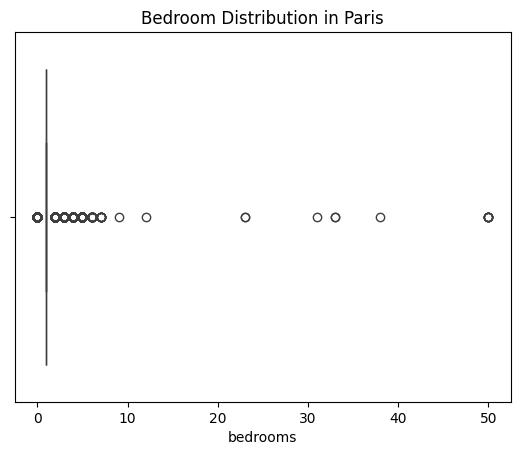

In [94]:
# The Boxplot is the best tool for seeing outliers
sns.boxplot(x=paris_df['bedrooms'])
plt.title('Bedroom Distribution in Paris')
plt.show()

In [95]:
def clean_bedroom_outliers(df, manual_cap=9):
    """
    Handles bedroom outliers using a combination of 
    Statistical Percentiles and Human Logic.
    """
    df_clean = df.copy()
    
    # --- Step 1: Statistical View ---
    # Find the value where 99% of Paris listings fall
    statistical_limit = df_clean['bedrooms'].quantile(0.99)
    
    # --- Step 2: Logic View ---
    # We use the SMALLER of the two. 
    # If the stats say 5 is the limit, but you want to allow up to 9, 
    # we choose 9 to be safe.
    final_limit = max(statistical_limit, manual_cap)
    
    # --- Step 3: Action ---
    # Identify how many are being removed
    outlier_count = len(df_clean[df_clean['bedrooms'] > final_limit])
    
    # Filter the data
    df_clean = df_clean[df_clean['bedrooms'] <= final_limit]
    
    print(f"--- Bedroom Outlier Report ---")
    print(f"99th Percentile (Stats): {statistical_limit} rooms")
    print(f"Manual Logic Cap: {manual_cap} rooms")
    print(f"Final Limit Applied: {final_limit} rooms")
    print(f"Removed {outlier_count} 'Extreme' listings (like the 50-bedroom error).")
    
    return df_clean

# Apply this to create your viz_df
viz_df = clean_bedroom_outliers(paris_df, manual_cap=9)

--- Bedroom Outlier Report ---
99th Percentile (Stats): 4.0 rooms
Manual Logic Cap: 9 rooms
Final Limit Applied: 9 rooms
Removed 14 'Extreme' listings (like the 50-bedroom error).


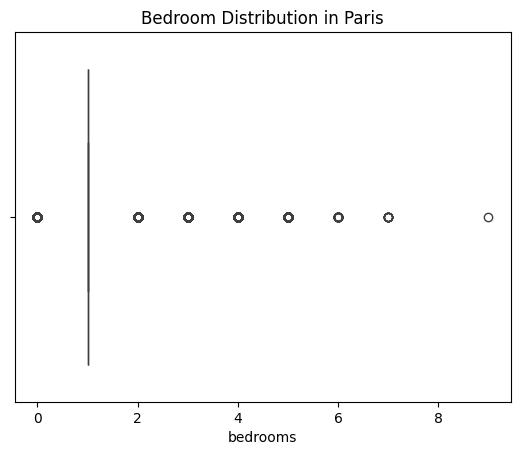

In [99]:
sns.boxplot(x=viz_df['bedrooms'])
plt.title('Bedroom Distribution in Paris')
plt.show()

In [100]:
# Save the cleaned visualization dataframe to a CSV
viz_df.to_csv('paris_airbnb_cleaned_viz.csv', index=False)

print("File saved successfully as 'paris_airbnb_cleaned_viz.csv'")

File saved successfully as 'paris_airbnb_cleaned_viz.csv'
